## Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.nn.init import xavier_uniform_
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Global Configuration

In [3]:
#------------ Assuming ground truth for Bete and Gamma ------------
TRUE_PARAMS = {'beta': 0.5, 'gamma': 0.05}

# ----Initializing Hyperparameters-------
MU_BETA_BASE   = 0.5
MU_GAMMA_BASE  = 0.05
SIGMA_BETA     = 0.2
SIGMA_GAMMA    = 0.02


lambda1 = 0.6
lambda2 = 0.3
lambda3 = 0.1

# -------------- Training settings -----------------
batch_size = 32
epochs     = 5000

# -------------- Experiment settings ---------------
NOISE_LEVELS  = [0.0, 0.05, 0.10, 0.20]
SEEDS         = [42, 123, 7]

HIDDEN_DIMS   = [50, 50, 50]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Noise Levels : {NOISE_LEVELS}')
print(f'Prior   : mu_beta={MU_BETA_BASE}, sigma_beta={SIGMA_BETA}, '
      f'mu_gamma={MU_GAMMA_BASE}, sigma_gamma={SIGMA_GAMMA}')

Device : cuda
Noise Levels : [0.0, 0.05, 0.1, 0.2]
Prior   : mu_beta=0.5, sigma_beta=0.2, mu_gamma=0.05, sigma_gamma=0.02


## 2. Data Loading and Noise Injection

In [4]:
def load_and_prepare_data(test_frac=0.1, val_frac=0.1):

    data_loaded = pd.read_csv('/content/drive/MyDrive/sir_data.csv')
    data_loaded = data_loaded.sort_values('time').reset_index(drop=True)

#  ------Separate Data into Time, Susceptible, Infected, Recovered----------

    t_all = data_loaded['time'].values.reshape(-1, 1)
    S_all = data_loaded['Susceptible'].values.reshape(-1, 1)
    I_all = data_loaded['Infected'].values.reshape(-1, 1)
    R_all = data_loaded['Recovered'].values.reshape(-1, 1)

 #------Assign value into variable for slipting------

    n       = len(data_loaded)
    n_test  = max(1, int(round(n * test_frac)))
    n_val   = max(1, int(round(n * val_frac)))
    n_train = n - n_test - n_val

 #--------Create Range for Data Preprossing--------

    train_sl = slice(0, n_train)
    val_sl   = slice(n_train, n_train + n_val)
    test_sl  = slice(n_train + n_val, n)

    return (
        t_all[train_sl],  t_all[val_sl],  t_all[test_sl],
        S_all[train_sl],  I_all[train_sl], R_all[train_sl],
        S_all[val_sl],    I_all[val_sl],   R_all[val_sl],
        S_all[test_sl],   I_all[test_sl],  R_all[test_sl]
    )


def add_gaussian_noise(S, I, R, noise_level, rng):
    def noisy(arr):
        if noise_level == 0.0:
            return arr.copy()
        sigma = noise_level * arr.std()
        return np.clip(arr + rng.normal(0, sigma, arr.shape), 0, 1)

    return noisy(S), noisy(I), noisy(R)


print('Data utilities defined.')

Data utilities defined.


In [5]:
# Load the clean split once — noise is added per-seed inside the experiment loop
(t_train_set,     t_val_set,       t_test_set,
 data_S_train_set, data_I_train_set, data_R_train_set,
 data_S_val_set,   data_I_val_set,   data_R_val_set,
 data_S_test_set,  data_I_test_set,  data_R_test_set) = load_and_prepare_data()

print(f'Train: {t_train_set.shape[0]} | Val: {t_val_set.shape[0]} | Test: {t_test_set.shape[0]}')
print(f'Time range -> train: [{t_train_set.min():.0f}, {t_train_set.max():.0f}]  '
      f'val: [{t_val_set.min():.0f}, {t_val_set.max():.0f}]  '
      f'test: [{t_test_set.min():.0f}, {t_test_set.max():.0f}]')

Train: 96 | Val: 12 | Test: 12
Time range -> train: [0, 80]  val: [81, 90]  test: [91, 100]


## 3. Model and Helper Functions

In [6]:
from torch.nn.init import xavier_uniform_

class SIRPINN(nn.Module):

    def __init__(self, input_dim=1, hidden_dims=[50, 50, 50], output_dim=3,
                 beta_init=1.0, gamma_init=1.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim,    hidden_dims[0]), nn.Tanh(),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[2]), nn.Tanh(),
            nn.Linear(hidden_dims[2], output_dim)
        )

  #----Initializing weight value through Xavier function-----

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)

  # ----── Initialization under test ──────

        self.params = nn.ParameterDict({
            'beta' : nn.Parameter(torch.tensor(float(beta_init))),
            'gamma': nn.Parameter(torch.tensor(float(gamma_init)))
        })

  #------ Default Function from Pytorch --------

    def forward(self, t):
        return self.network(t)


def to_tensor(x, device, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)



#-------- Create Tensor through Pytorch ----------

def prepare_dataloader(t, S, I, R, batch_size, device):
    dataset = TensorDataset(
        to_tensor(t, device, requires_grad=True),
        to_tensor(S, device),
        to_tensor(I, device),
        to_tensor(R, device)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


print('SIRPINN, to_tensor, prepare_dataloader defined.')

SIRPINN, to_tensor, prepare_dataloader defined.


##.Pre-compute Shared Tensors

In [7]:
t_val_tensor        = to_tensor(t_val_set,       device)
data_S_val_tensor   = to_tensor(data_S_val_set,  device)
data_I_val_tensor   = to_tensor(data_I_val_set,  device)
data_R_val_tensor   = to_tensor(data_R_val_set,  device)

t_train_tensor      = to_tensor(t_train_set,      device, requires_grad=True)
data_S_train_tensor = to_tensor(data_S_train_set, device)
data_I_train_tensor = to_tensor(data_I_train_set, device)
data_R_train_tensor = to_tensor(data_R_train_set, device)

t_test_tensor       = to_tensor(t_test_set,       device)

print('All tensors ready.')

All tensors ready.


## 4. trainig Function



In [8]:
def train_standard_pinn(
        model, optimizer, train_loader_local,
        t_val_tensor, data_S_val_tensor, data_I_val_tensor, data_R_val_tensor,
        epochs,
        patience=1500, min_delta=1e-5,
        verbose=False):
    train_losses        = []
    val_losses          = []
    parameter_estimates = {'beta': [], 'gamma': []}
    best_val_loss       = float('inf')
    epochs_without_improvement = 0
    best_model_state    = None
    best_beta=None
    best_gamma=None


  # ------- Train Model --------

    for epoch in range(epochs):
        model.train()
        epoch_batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader_local:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            output = model(t_batch)
            S_pred = output[:, 0:1]
            I_pred = output[:, 1:2]
            R_pred = output[:, 2:3]

            beta  = model.params['beta']
            gamma = model.params['gamma']

            dS_dt = torch.autograd.grad(S_pred, t_batch,
                        grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch,
                        grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch,
                        grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
                            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
                            torch.mean((dR_dt - gamma * I_pred)**2))

            data_loss = (torch.mean((S_pred - S_batch)**2) +
                         torch.mean((I_pred - I_batch)**2) +
                         torch.mean((R_pred - R_batch)**2))

  # --------- Standard PINN: NO prior term --------------

            loss = 0.3 * physics_loss + 0.6 * data_loss
            loss.backward()
            optimizer.step()
            epoch_batch_losses.append(loss.item())

        epoch_train_loss = np.mean(epoch_batch_losses)
        train_losses.append(epoch_train_loss)
        parameter_estimates['beta'].append(model.params['beta'].item())
        parameter_estimates['gamma'].append(model.params['gamma'].item())

        model.eval()
        with torch.no_grad():
            out_val = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:,0:1] - data_S_val_tensor)**2) +
                        torch.mean((out_val[:,1:2] - data_I_val_tensor)**2) +
                        torch.mean((out_val[:,2:3] - data_R_val_tensor)**2)).item()
            val_losses.append(val_loss)

        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            best_beta    = model.params['beta'].item()
            best_gamma   = model.params['gamma'].item()
            epochs_without_improvement = 0
            best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f'    Early stopping at epoch {epoch}  (best val={best_val_loss:.6f}) (Best_beta={best_beta:4f}) (Best_gamma={best_gamma:4f})')
            break

        if verbose and epoch % 500 == 0:
            print(f'    Epoch {epoch:5d} | beta={model.params["beta"].item():.4f} '
                  f'gamma={model.params["gamma"].item():.5f} | val={val_loss:.6f}')

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, parameter_estimates


def train_with_physics_loss_sir(
        model, optimizer, train_loader_local,
        epochs,
        t_train_tensor, data_S_train_tensor, data_I_train_tensor, data_R_train_tensor,
        t_val_tensor,   data_S_val_tensor,   data_I_val_tensor,   data_R_val_tensor,
        mu_beta_prior, sigma_beta_prior,
        mu_gamma_prior, sigma_gamma_prior,
        lambda1=0.6, lambda2=0.3, lambda3=0.1,
        patience=1500, min_delta=1e-5,
        verbose=False):
    train_losses        = []
    val_losses          = []
    parameter_estimates = {'beta': [], 'gamma': []}
    best_val_loss       = float('inf')
    best_beta          = None
    best_gamma         = None
    epochs_without_improvement = 0
    best_model_state    = None

    for epoch in range(epochs):
        model.train()
        epoch_batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader_local:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            output = model(t_batch)
            S_pred = output[:, 0:1]
            I_pred = output[:, 1:2]
            R_pred = output[:, 2:3]

            beta  = model.params['beta']
            gamma = model.params['gamma']

            dS_dt = torch.autograd.grad(S_pred, t_batch,
                        grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch,
                        grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch,
                        grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
                            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
                            torch.mean((dR_dt - gamma * I_pred)**2))

            data_loss = (torch.mean((S_pred - S_batch)**2) +
                         torch.mean((I_pred - I_batch)**2) +
                         torch.mean((R_pred - R_batch)**2))

            prior_loss = ((beta  - mu_beta_prior )**2 / (2 * sigma_beta_prior**2) +
                          (gamma - mu_gamma_prior)**2 / (2 * sigma_gamma_prior**2))

            loss = lambda2 * physics_loss + lambda1 * data_loss + lambda3 * prior_loss
            loss.backward()
            optimizer.step()
            epoch_batch_losses.append(loss.item())

        epoch_train_loss = np.mean(epoch_batch_losses)
        train_losses.append(epoch_train_loss)
        parameter_estimates['beta'].append(model.params['beta'].item())
        parameter_estimates['gamma'].append(model.params['gamma'].item())

        model.eval()
        with torch.no_grad():
            out_val = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:,0:1] - data_S_val_tensor)**2) +
                        torch.mean((out_val[:,1:2] - data_I_val_tensor)**2) +
                        torch.mean((out_val[:,2:3] - data_R_val_tensor)**2)).item()
            val_losses.append(val_loss)

        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            best_beta    = model.params['beta'].item()
            best_gamma   = model.params['gamma'].item()
            epochs_without_improvement = 0
            best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f'    Early stopping at epoch {epoch} (best val={best_val_loss:.6f}) (Best_beta={best_beta:4f}) (Best_gamma={best_gamma:4f})')
            break

        if verbose and epoch % 500 == 0:
            print(f'    Epoch {epoch:5d} | beta={beta.item():.4f} '
                  f'gamma={gamma.item():.5f} | val={val_loss:.6f}')

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, parameter_estimates


print('Both training functions defined.')

Both training functions defined.


## 5. Main Noise Robustness Experiment

**4 noise levels × 2 models × 3 seeds = 24 training runs**

In [ ]:
def get_fresh_model_and_optimizer(seed, beta_init, gamma_init):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m   = SIRPINN(input_dim=1, hidden_dims=[50, 50, 50], output_dim=3,
                  beta_init=beta_init, gamma_init=gamma_init).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    return m, opt


def get_fresh_loader(seed, S, I, R):
    torch.manual_seed(seed)
    return prepare_dataloader(
        t_train_set, S, I, R,
        batch_size, device)


# ── Results container ──────────────────────────────────────────────
noise_results = []   # list of dicts, one per noise level

total_runs = len(NOISE_LEVELS) * 2 * len(SEEDS)
run_ctr    = 0

for noise_lvl in NOISE_LEVELS:
    pinn_beta_errs, pinn_gamma_errs     = [], []
    pipinn_beta_errs, pipinn_gamma_errs = [], []
    pinn_traces, pipinn_traces          = [], []

    noise_pct = int(noise_lvl * 100)
    print(f'\n══ Noise Level: {noise_pct}% ═══════════════════════════════')

    for seed in SEEDS:

        rng = np.random.default_rng(seed)

        #------------- Add noise------------
        S_tr_n, I_tr_n, R_tr_n = add_gaussian_noise(
            data_S_train_set, data_I_train_set, data_R_train_set, noise_lvl, rng)
        S_vl_n, I_vl_n, R_vl_n = add_gaussian_noise(
            data_S_val_set,   data_I_val_set,   data_R_val_set, noise_lvl, rng)


        t_tr_t = to_tensor(t_train_set, device, requires_grad=True)
        S_tr_t = to_tensor(S_tr_n, device)
        I_tr_t = to_tensor(I_tr_n, device)
        R_tr_t = to_tensor(R_tr_n, device)

        t_vl_t = to_tensor(t_val_set,   device)
        S_vl_t = to_tensor(S_vl_n,  device)
        I_vl_t = to_tensor(I_vl_n,  device)
        R_vl_t = to_tensor(R_vl_n,  device)

        # --------------Standard PINN --------------
        run_ctr += 1
        print(f'  [{run_ctr}/{total_runs}]  PINN  | noise={noise_pct}% | seed={seed}')

        m_p, opt_p = get_fresh_model_and_optimizer(seed, 1.0, 1.0)
        loader_p   = get_fresh_loader(seed, S_tr_n, I_tr_n, R_tr_n)
        _, _, p_est_p = train_standard_pinn(
                  model=m_p, optimizer=opt_p, train_loader_local=loader_p,
                  t_val_tensor=t_vl_t,
                  data_S_val_tensor=S_vl_t,
                  data_I_val_tensor=I_vl_t,
                  data_R_val_tensor=R_vl_t,
                  epochs=epochs,
                  verbose=True
              )

        fb_p = m_p.params['beta'].item()
        fg_p = m_p.params['gamma'].item()
        # print(fb_p)
        # print(fg_p)
        pinn_beta_errs.append( abs(fb_p - TRUE_PARAMS['beta'])  / TRUE_PARAMS['beta']  * 100)
        pinn_gamma_errs.append(abs(fg_p - TRUE_PARAMS['gamma']) / TRUE_PARAMS['gamma'] * 100)
        pinn_traces.append(p_est_p )

        # ----------------- PI-PINN -----------------
        run_ctr += 1
        print(f'  [{run_ctr}/{total_runs}] PI-PINN | noise={noise_pct}% | seed={seed}')

        m_pi, opt_pi = get_fresh_model_and_optimizer(seed, 1.0, 1.0)
        loader_pi    = get_fresh_loader(seed, S_tr_n, I_tr_n, R_tr_n)

        _, _, p_est_pi = train_with_physics_loss_sir(
            model=m_pi, optimizer=opt_pi, train_loader_local=loader_pi,
            epochs=epochs,
            t_train_tensor=t_tr_t,
            data_S_train_tensor=S_tr_t,
            data_I_train_tensor=I_tr_t,
            data_R_train_tensor=R_tr_t,
            t_val_tensor=t_vl_t,
            data_S_val_tensor=S_vl_t,
            data_I_val_tensor=I_vl_t,
            data_R_val_tensor=R_vl_t,
            mu_beta_prior=MU_BETA_BASE,   sigma_beta_prior=SIGMA_BETA,
            mu_gamma_prior=MU_GAMMA_BASE, sigma_gamma_prior=SIGMA_GAMMA,
            lambda1=lambda1, lambda2=lambda2, lambda3=lambda3,
            verbose=True
        )

        fb_pi = m_pi.params['beta'].item()
        fg_pi = m_pi.params['gamma'].item()
        # print(fb_pi)
        # print(fg_pi)
        pipinn_beta_errs.append( abs(fb_pi - TRUE_PARAMS['beta'])  / TRUE_PARAMS['beta']  * 100)
        pipinn_gamma_errs.append(abs(fg_pi - TRUE_PARAMS['gamma']) / TRUE_PARAMS['gamma'] * 100)
        pipinn_traces.append(p_est_pi)

    noise_results.append({
        'noise_pct'         : noise_pct,
        'pinn_beta_mean'    : np.mean(pinn_beta_errs),
        'pinn_beta_std'     : np.std(pinn_beta_errs),
        'pinn_gamma_mean'   : np.mean(pinn_gamma_errs),
        'pinn_gamma_std'    : np.std(pinn_gamma_errs),
        'pipinn_beta_mean'  : np.mean(pipinn_beta_errs),
        'pipinn_beta_std'   : np.std(pipinn_beta_errs),
        'pipinn_gamma_mean' : np.mean(pipinn_gamma_errs),
        'pipinn_gamma_std'  : np.std(pipinn_gamma_errs),
        'pinn_traces'       : pinn_traces,
        'pipinn_traces'     : pipinn_traces,
    })

print('\n Noise robustness experiment complete.')



══ Noise Level: 0% ═══════════════════════════════
  [1/24]  PINN  | noise=0% | seed=42
    Epoch     0 | beta=0.9976 gamma=0.99745 | val=1.351515
    Epoch   500 | beta=0.7496 gamma=0.07042 | val=0.000161
    Epoch  1000 | beta=0.4828 gamma=0.04995 | val=0.000321
    Epoch  1500 | beta=0.4830 gamma=0.04951 | val=0.000774
    Epoch  2000 | beta=0.4911 gamma=0.04968 | val=0.000070
    Epoch  2500 | beta=0.4954 gamma=0.04976 | val=0.000420
    Epoch  3000 | beta=0.4986 gamma=0.04991 | val=0.000020
    Early stopping at epoch 3335  (best val=0.000003) (Best_beta=0.489483) (Best_gamma=0.049817)
0.48948341608047485
0.049816567450761795
  [2/24] PI-PINN | noise=0% | seed=42
    Epoch     0 | beta=0.9970 gamma=0.99700 | val=1.351519
    Epoch   500 | beta=0.5006 gamma=0.11922 | val=0.000152
    Epoch  1000 | beta=0.5000 gamma=0.05009 | val=0.000446
    Epoch  1500 | beta=0.5000 gamma=0.05000 | val=0.000693
    Epoch  2000 | beta=0.5000 gamma=0.05000 | val=0.000078
    Epoch  2500 | beta=0.50

## 6.  Error Table

In [13]:

SEP  = '═' * 100
SEP2 = '─' * 100

print(SEP)
print('TABLE 1: Parameter Recovery Under Noisy Observations  (mean ± std, n=3 seeds)')
print(SEP)
print(f"{'Noise':>7}  "
      f"{'PINN β err (%)':>26}  "
      f"{'PINN γ err (%)':>26}  "
      f"{'PI-PINN β err (%)':>22}  "
      f"{'PI-PINN γ err (%)':>22}")
print(f"{'Level':>7}  ")
print(SEP2)

for r in noise_results:
    print(f"{str(r['noise_pct'])+'%':>7}  "
          f"{r['pinn_beta_mean']:>14.2f} ± {r['pinn_beta_std']:>6.2f}   "
          f"{r['pinn_gamma_mean']:>14.2f} ± {r['pinn_gamma_std']:>6.2f}   "
          f"{r['pipinn_beta_mean']:>10.2f} ± {r['pipinn_beta_std']:>6.2f}   "
          f"{r['pipinn_gamma_mean']:>10.2f} ± {r['pipinn_gamma_std']:>6.2f}")

print(SEP)
print(f'Ground truth: β = {TRUE_PARAMS["beta"]}, γ = {TRUE_PARAMS["gamma"]}')

════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE 1: Parameter Recovery Under Noisy Observations  (mean ± std, n=3 seeds)
════════════════════════════════════════════════════════════════════════════════════════════════════
  Noise              PINN β err (%)              PINN γ err (%)       PI-PINN β err (%)       PI-PINN γ err (%)
  Level  
────────────────────────────────────────────────────────────────────────────────────────────────────
     0%           93.08 ±  64.61           610.69 ± 455.76        11.87 ±  10.83       574.54 ± 429.07
     5%            4.23 ±   0.47             0.80 ±   0.89         1.34 ±   1.64       233.28 ± 200.44
    10%           41.92 ±  50.13           160.65 ± 225.42         8.83 ±   6.88       521.20 ± 374.52
    20%           21.49 ±  22.25            20.30 ±  23.55         0.01 ±   0.01         8.51 ±  12.03
═════════════════════════════════════════════════════════════════════════════════════

## 7. Figure A — Bar Chart: β and γ Errors Across Noise Levels

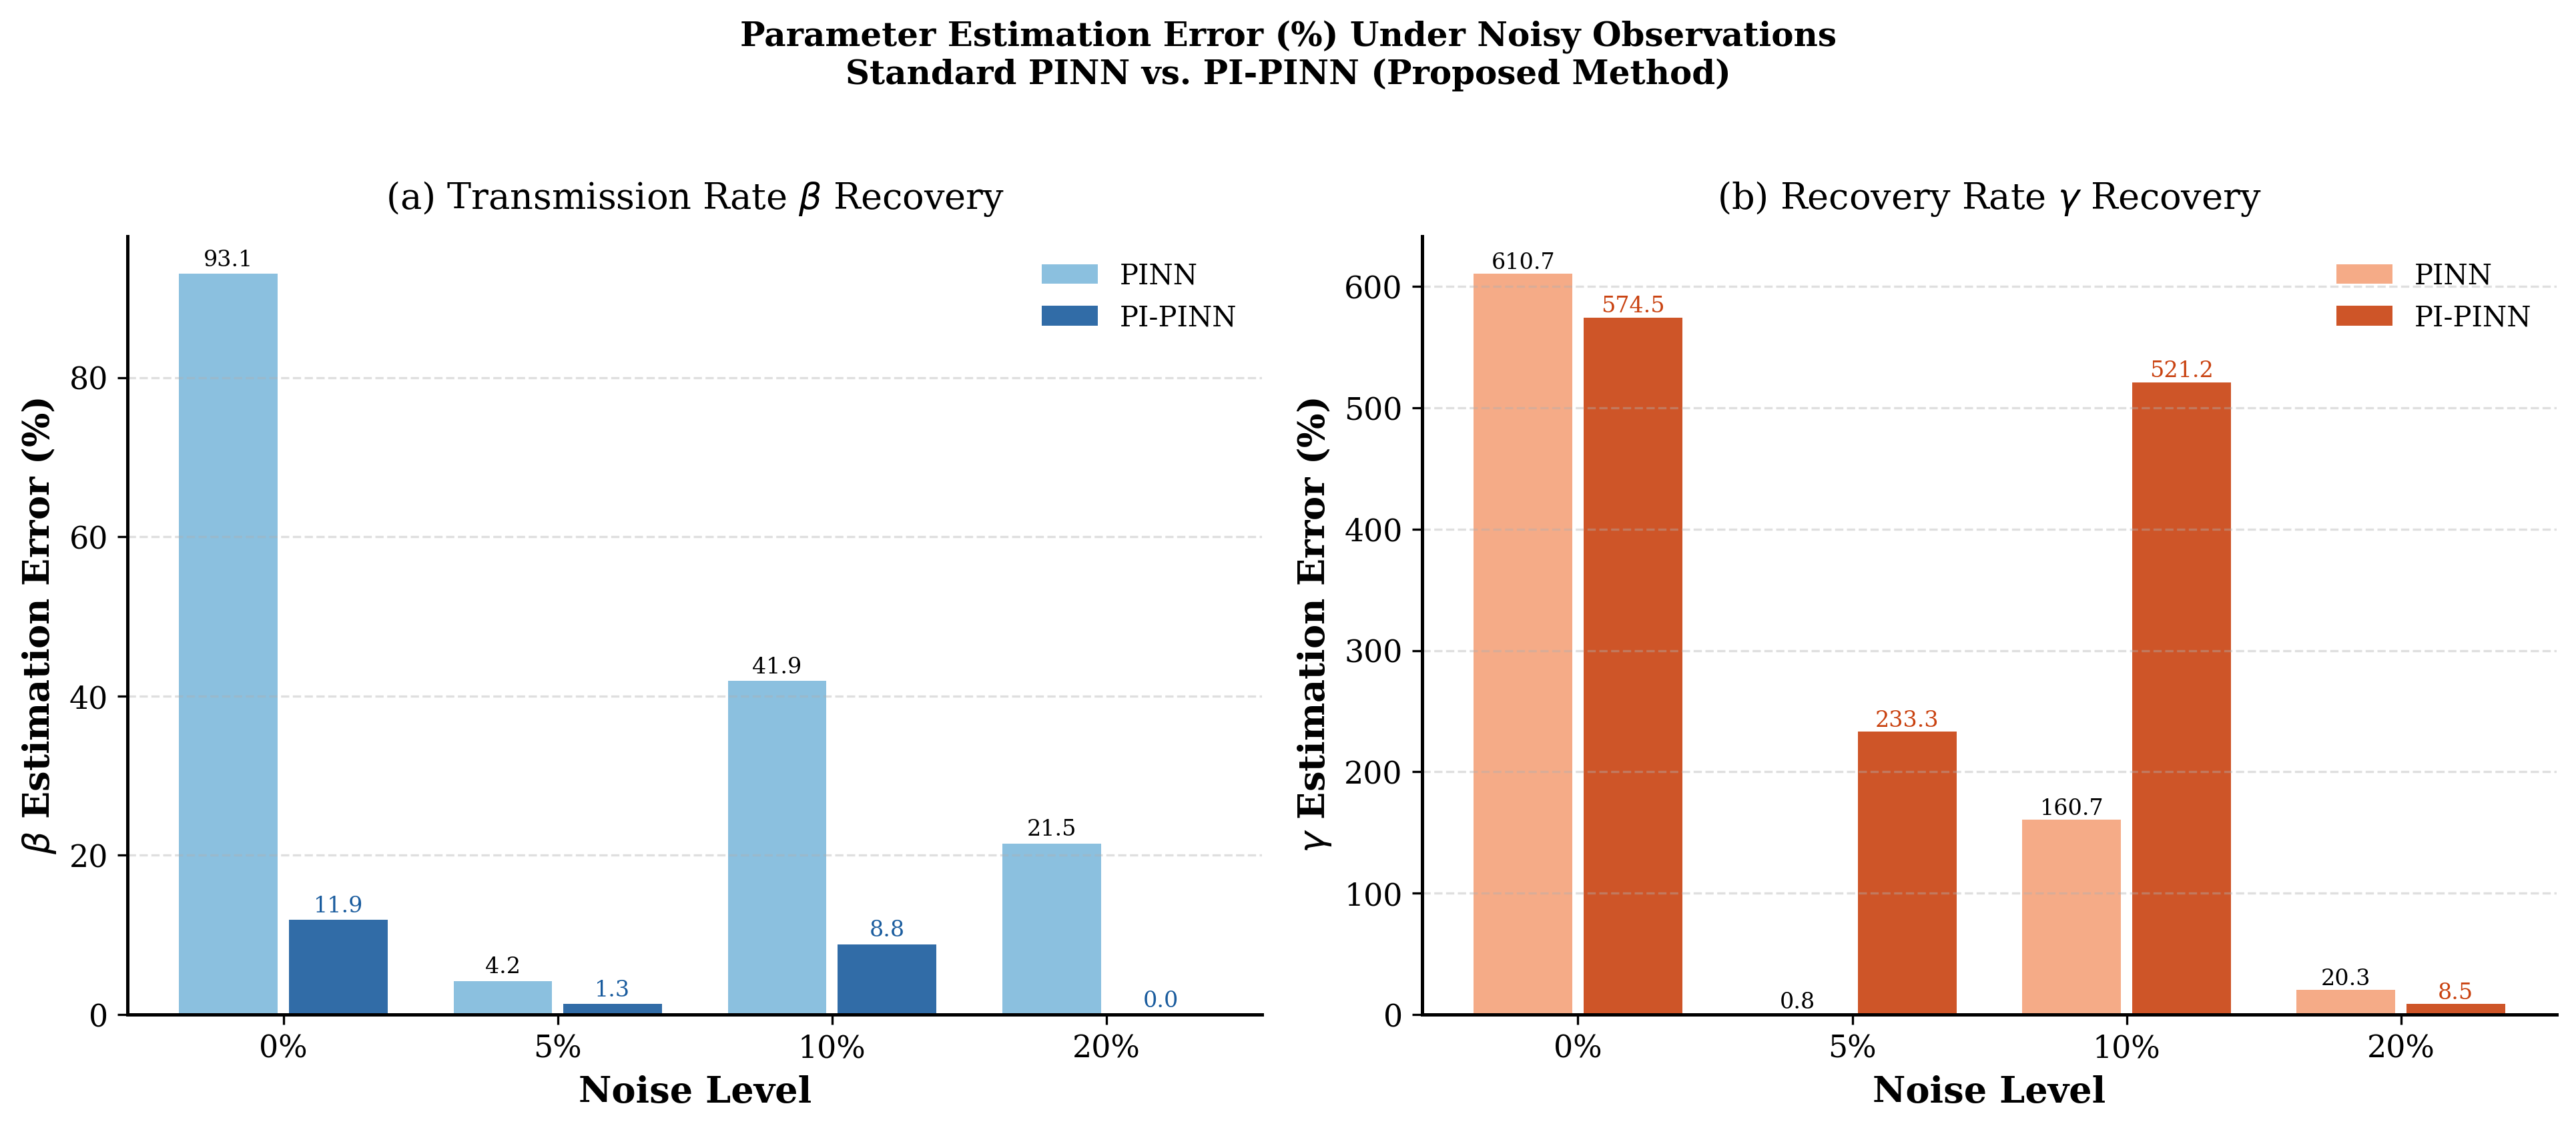

Saved: Fig_Noise_Robustness_Bar.png


In [15]:
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 10,
    'axes.linewidth' : 1.2,
})

noise_labels  = [f"{r['noise_pct']}%" for r in noise_results]
x             = np.arange(len(noise_labels))
w             = 0.20

pinn_b_m   = [r['pinn_beta_mean']    for r in noise_results]
pinn_g_m   = [r['pinn_gamma_mean']   for r in noise_results]
pi_b_m     = [r['pipinn_beta_mean']  for r in noise_results]
pi_g_m     = [r['pipinn_gamma_mean'] for r in noise_results]

# Colors: PINN = muted, PI-PINN = vivid
C_PINN_B   = '#7fbadc'   # light blue
C_PINN_G   = '#f4a27a'   # light orange
C_PIPINN_B = '#1a5c9e'   # deep blue
C_PIPINN_G = '#c94210'   # deep red-orange

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=300)

# ── Left: Beta error ──────────────────────────────────────────────
ax = axes[0]
bars_pb = ax.bar(x - w, pinn_b_m,  w*1.8, label='PINN',
                  color=C_PINN_B, alpha=0.9)
bars_ib = ax.bar(x + w, pi_b_m,    w*1.8, label='PI-PINN',
                  color=C_PIPINN_B, alpha=0.9)

for bar in bars_pb:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_ib:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color=C_PIPINN_B)

ax.set_xlabel('Noise Level', fontweight='bold')
ax.set_ylabel(r'$\beta$ Estimation Error (%)', fontweight='bold')
ax.set_title(r'(a) Transmission Rate $\beta$ Recovery', pad=10)
ax.set_xticks(x); ax.set_xticklabels(noise_labels)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Right: Gamma error ────────────────────────────────────────────
ax = axes[1]
bars_pg = ax.bar(x - w, pinn_g_m,  w*1.8, label='PINN',
                  color=C_PINN_G, alpha=0.9)
bars_ig = ax.bar(x + w, pi_g_m,    w*1.8, label='PI-PINN',
                  color=C_PIPINN_G, alpha=0.9)

for bar in bars_pg:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_ig:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color=C_PIPINN_G)

ax.set_xlabel('Noise Level', fontweight='bold')
ax.set_ylabel(r'$\gamma$ Estimation Error (%)', fontweight='bold')
ax.set_title(r'(b) Recovery Rate $\gamma$ Recovery', pad=10)
ax.set_xticks(x); ax.set_xticklabels(noise_labels)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Parameter Estimation Error (%) Under Noisy Observations\n'
    'Standard PINN vs. PI-PINN (Proposed Method)',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Fig_Noise_Robustness_Bar.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Noise_Robustness_Bar.png')